In [ ]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

class NCSNConfig:
    # Noise Levels
    sigma_begin = 30.0
    sigma_end = 0.01
    num_levels = 10

    # Training
    batch_size = 64

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = NCSNConfig()
print(f"Device set to: {cfg.device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, drop_last=True)

sample_batch, _ = next(iter(train_loader))

sigmas = torch.exp(torch.linspace(
    np.log(cfg.sigma_begin),
    np.log(cfg.sigma_end),
    cfg.num_levels
)).to(cfg.device)

print("\nGenerated Sigma Sequence (Geometric):")
print(sigmas)

Device set to: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.11MB/s]



Generated Sigma Sequence (Geometric):
tensor([3.0000e+01, 1.2325e+01, 5.0632e+00, 2.0801e+00, 8.5454e-01, 3.5106e-01,
        1.4422e-01, 5.9251e-02, 2.4341e-02, 1.0000e-02], device='cuda:0')


In [ ]:
# Network Building Blocks
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim=256, scale=30.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class Dense(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)
        self.act = nn.SiLU()

    def forward(self, x):
        return self.dense(self.act(x))

class AdaptiveResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, embed_dim=256):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

        self.embed_layers = nn.Linear(embed_dim, 2 * in_channels)

    def forward(self, x, embed):
        h = self.norm1(x)

        style = self.embed_layers(embed)
        style = style.unsqueeze(2).unsqueeze(3)
        scale, shift = style.chunk(2, dim=1)

        h = h * (1 + scale) + shift

        h = F.silu(h)
        h = self.conv1(h)

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + self.shortcut(x)

In [ ]:
# ScoreNet U-Net Architecture
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=256),
            Dense(256, 256)
        )

        self.input_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)

        self.enc1 = AdaptiveResBlock(64, 64)
        self.down1 = nn.AvgPool2d(2)

        self.enc2 = AdaptiveResBlock(64, 128)
        self.down2 = nn.AvgPool2d(2)

        self.enc3 = AdaptiveResBlock(128, 256)

        self.dec1 = AdaptiveResBlock(256 + 128, 128)

        self.dec2 = AdaptiveResBlock(128 + 64, 64)

        self.output_conv = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x, sigma):

        embed = self.embed(sigma)

        x1 = self.input_conv(x)
        x1 = self.enc1(x1, embed)

        x2 = self.down1(x1)
        x2 = self.enc2(x2, embed)

        x3 = self.down2(x2)
        x3 = self.enc3(x3, embed)

        u1 = F.interpolate(x3, scale_factor=2, mode='nearest')
        u1 = torch.cat([u1, x2], dim=1)
        d1 = self.dec1(u1, embed)

        u2 = F.interpolate(d1, scale_factor=2, mode='nearest')
        u2 = torch.cat([u2, x1], dim=1)
        d2 = self.dec2(u2, embed)

        out = self.output_conv(d2)

        out = out / sigma[:, None, None, None]

        return out


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ScoreNet().to(device)

In [ ]:
# Loss Function and Annealed Langevin Sampling
def calc_loss(model, x, sigmas):
    B = x.shape[0]

    sigma_indices = torch.randint(0, len(sigmas), (B,), device=x.device)
    current_sigmas = sigmas[sigma_indices]

    z = torch.randn_like(x)

    sigmas_reshaped = current_sigmas.view(B, 1, 1, 1)
    x_tilde = x + sigmas_reshaped * z

    pred_score = model(x_tilde, current_sigmas)

    target = -z / sigmas_reshaped

    loss = 0.5 * ((pred_score * sigmas_reshaped + z) ** 2).sum() / B
    return loss

@torch.no_grad()
def annealed_langevin_sampling(model, sigmas, n_steps=100, step_lr=2e-5, final_only=True):
    model.eval()

    B = 16
    x = torch.rand(B, 1, 28, 28, device=sigmas.device)
    x = torch.rand(B, 1, 28, 28, device=sigmas.device)

    trajectory = []

    for i, sigma in enumerate(sigmas):
        sigma_val = sigma.item()

        step_size = step_lr * (sigma_val / sigmas[-1].item()) ** 2

        for t in range(n_steps):
            sigma_batch = torch.full((B,), sigma_val, device=sigmas.device)

            grad = model(x, sigma_batch)

            z = torch.randn_like(x)
            x = x + step_size * grad + np.sqrt(2 * step_size) * z

        if not final_only:
            trajectory.append(x.clone().cpu())

    return x if final_only else trajectory

Config Updated: LR=0.0001, Epochs=30, Steps=100
Starting training from scratch...
Training Started...
Epoch 0 | Step 0 | Loss: 1381.17944
Epoch 0 | Step 100 | Loss: 112.13995
Epoch 0 | Step 200 | Loss: 64.59848
Epoch 0 | Step 300 | Loss: 48.68366
Epoch 0 | Step 400 | Loss: 58.80920
Epoch 0 | Step 500 | Loss: 53.14413
Epoch 0 | Step 600 | Loss: 37.05933
Epoch 0 | Step 700 | Loss: 37.37008
Epoch 0 | Step 800 | Loss: 33.64322
Epoch 0 | Step 900 | Loss: 38.33897
=== Epoch 0 Finished | Avg Loss: 70.53343 | Time: 54.5s ===
Generating samples...


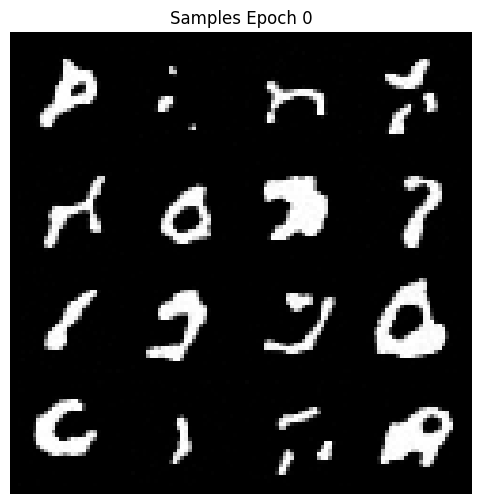

Epoch 1 | Step 0 | Loss: 40.51202
Epoch 1 | Step 100 | Loss: 39.25987
Epoch 1 | Step 200 | Loss: 35.03102
Epoch 1 | Step 300 | Loss: 36.04308
Epoch 1 | Step 400 | Loss: 31.10998
Epoch 1 | Step 500 | Loss: 30.82060
Epoch 1 | Step 600 | Loss: 25.82925
Epoch 1 | Step 700 | Loss: 35.95850
Epoch 1 | Step 800 | Loss: 26.40300
Epoch 1 | Step 900 | Loss: 23.76555
=== Epoch 1 Finished | Avg Loss: 34.22382 | Time: 53.4s ===
Epoch 2 | Step 0 | Loss: 35.62445
Epoch 2 | Step 100 | Loss: 37.25731
Epoch 2 | Step 200 | Loss: 28.55236
Epoch 2 | Step 300 | Loss: 25.52097
Epoch 2 | Step 400 | Loss: 33.74949
Epoch 2 | Step 500 | Loss: 30.58736
Epoch 2 | Step 600 | Loss: 30.13422
Epoch 2 | Step 700 | Loss: 36.49201
Epoch 2 | Step 800 | Loss: 32.57024
Epoch 2 | Step 900 | Loss: 32.17349
=== Epoch 2 Finished | Avg Loss: 30.95579 | Time: 52.9s ===
Epoch 3 | Step 0 | Loss: 40.88459
Epoch 3 | Step 100 | Loss: 27.56314
Epoch 3 | Step 200 | Loss: 27.90321
Epoch 3 | Step 300 | Loss: 28.97684
Epoch 3 | Step 400 | L

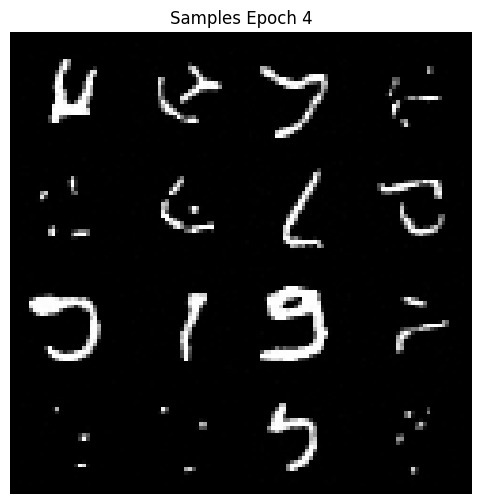

Epoch 5 | Step 0 | Loss: 23.99391
Epoch 5 | Step 100 | Loss: 27.82436
Epoch 5 | Step 200 | Loss: 28.35492
Epoch 5 | Step 300 | Loss: 25.03608
Epoch 5 | Step 400 | Loss: 26.87189
Epoch 5 | Step 500 | Loss: 25.29524
Epoch 5 | Step 600 | Loss: 27.34617
Epoch 5 | Step 700 | Loss: 24.32447
Epoch 5 | Step 800 | Loss: 33.02477
Epoch 5 | Step 900 | Loss: 22.48552
=== Epoch 5 Finished | Avg Loss: 27.28504 | Time: 53.3s ===
Epoch 6 | Step 0 | Loss: 28.80304
Epoch 6 | Step 100 | Loss: 26.96791
Epoch 6 | Step 200 | Loss: 25.27686
Epoch 6 | Step 300 | Loss: 26.54866
Epoch 6 | Step 400 | Loss: 26.59860
Epoch 6 | Step 500 | Loss: 31.45340
Epoch 6 | Step 600 | Loss: 29.42754
Epoch 6 | Step 700 | Loss: 27.70996
Epoch 6 | Step 800 | Loss: 28.70382
Epoch 6 | Step 900 | Loss: 29.72552
=== Epoch 6 Finished | Avg Loss: 27.05150 | Time: 52.9s ===
Epoch 7 | Step 0 | Loss: 28.45908
Epoch 7 | Step 100 | Loss: 28.62460
Epoch 7 | Step 200 | Loss: 22.95644
Epoch 7 | Step 300 | Loss: 25.51761
Epoch 7 | Step 400 | L

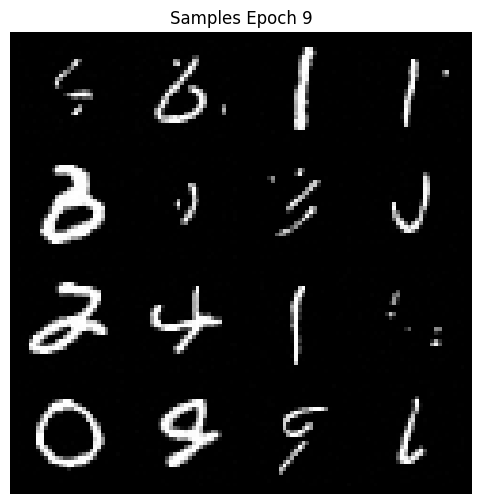

Epoch 10 | Step 0 | Loss: 22.75106
Epoch 10 | Step 100 | Loss: 30.56175
Epoch 10 | Step 200 | Loss: 18.65030
Epoch 10 | Step 300 | Loss: 22.85330
Epoch 10 | Step 400 | Loss: 27.66504
Epoch 10 | Step 500 | Loss: 29.40847
Epoch 10 | Step 600 | Loss: 32.82404
Epoch 10 | Step 700 | Loss: 23.48377
Epoch 10 | Step 800 | Loss: 26.99193
Epoch 10 | Step 900 | Loss: 26.94421
=== Epoch 10 Finished | Avg Loss: 25.63175 | Time: 52.9s ===
Epoch 11 | Step 0 | Loss: 34.65754
Epoch 11 | Step 100 | Loss: 29.67790
Epoch 11 | Step 200 | Loss: 29.00470
Epoch 11 | Step 300 | Loss: 30.03102
Epoch 11 | Step 400 | Loss: 24.59869
Epoch 11 | Step 500 | Loss: 28.20746
Epoch 11 | Step 600 | Loss: 26.52240
Epoch 11 | Step 700 | Loss: 20.98318
Epoch 11 | Step 800 | Loss: 33.11042
Epoch 11 | Step 900 | Loss: 23.50754
=== Epoch 11 Finished | Avg Loss: 25.62122 | Time: 53.1s ===
Epoch 12 | Step 0 | Loss: 22.35352
Epoch 12 | Step 100 | Loss: 26.85297
Epoch 12 | Step 200 | Loss: 30.38977
Epoch 12 | Step 300 | Loss: 24.69

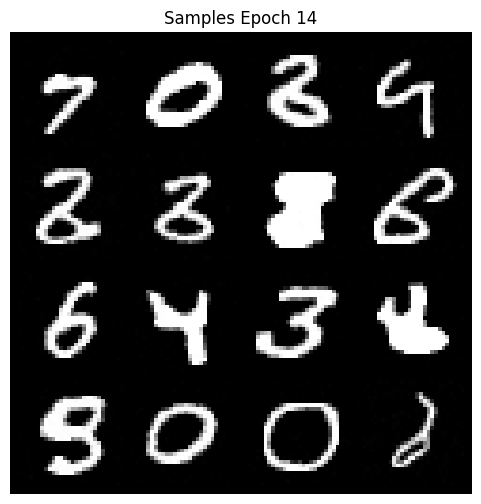

Epoch 15 | Step 0 | Loss: 22.74914
Epoch 15 | Step 100 | Loss: 27.90572
Epoch 15 | Step 200 | Loss: 23.37013
Epoch 15 | Step 300 | Loss: 23.94832
Epoch 15 | Step 400 | Loss: 30.03501
Epoch 15 | Step 500 | Loss: 22.16374
Epoch 15 | Step 600 | Loss: 25.75377
Epoch 15 | Step 700 | Loss: 20.65826
Epoch 15 | Step 800 | Loss: 27.44156
Epoch 15 | Step 900 | Loss: 25.14384
=== Epoch 15 Finished | Avg Loss: 24.79209 | Time: 52.9s ===
Epoch 16 | Step 0 | Loss: 20.23296
Epoch 16 | Step 100 | Loss: 21.71059
Epoch 16 | Step 200 | Loss: 25.90173
Epoch 16 | Step 300 | Loss: 24.49413
Epoch 16 | Step 400 | Loss: 24.75811
Epoch 16 | Step 500 | Loss: 23.82675
Epoch 16 | Step 600 | Loss: 21.60257
Epoch 16 | Step 700 | Loss: 21.91556
Epoch 16 | Step 800 | Loss: 21.61539
Epoch 16 | Step 900 | Loss: 26.74165
=== Epoch 16 Finished | Avg Loss: 24.77446 | Time: 52.9s ===
Epoch 17 | Step 0 | Loss: 23.10740
Epoch 17 | Step 100 | Loss: 27.78811
Epoch 17 | Step 200 | Loss: 26.05703
Epoch 17 | Step 300 | Loss: 31.15

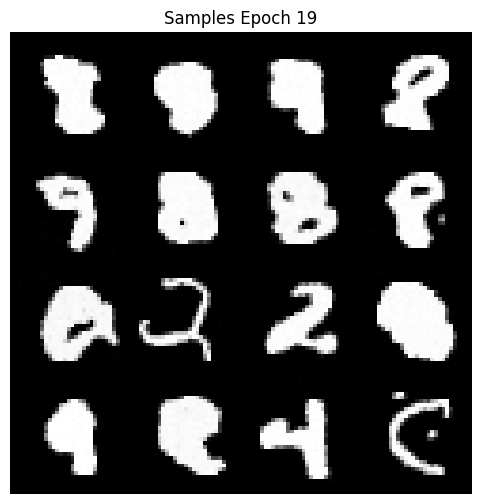

Epoch 20 | Step 0 | Loss: 23.08979
Epoch 20 | Step 100 | Loss: 27.70123
Epoch 20 | Step 200 | Loss: 27.03684
Epoch 20 | Step 300 | Loss: 17.86492
Epoch 20 | Step 400 | Loss: 22.68224
Epoch 20 | Step 500 | Loss: 25.92305
Epoch 20 | Step 600 | Loss: 20.47660
Epoch 20 | Step 700 | Loss: 24.63605
Epoch 20 | Step 800 | Loss: 22.05586
Epoch 20 | Step 900 | Loss: 23.23240
=== Epoch 20 Finished | Avg Loss: 24.49597 | Time: 53.1s ===
Epoch 21 | Step 0 | Loss: 22.33455
Epoch 21 | Step 100 | Loss: 24.71130
Epoch 21 | Step 200 | Loss: 27.38497
Epoch 21 | Step 300 | Loss: 18.09749
Epoch 21 | Step 400 | Loss: 27.45558
Epoch 21 | Step 500 | Loss: 23.50258
Epoch 21 | Step 600 | Loss: 23.70350
Epoch 21 | Step 700 | Loss: 20.76621
Epoch 21 | Step 800 | Loss: 23.32399
Epoch 21 | Step 900 | Loss: 24.36096
=== Epoch 21 Finished | Avg Loss: 24.65886 | Time: 52.8s ===
Epoch 22 | Step 0 | Loss: 28.75885
Epoch 22 | Step 100 | Loss: 24.39516
Epoch 22 | Step 200 | Loss: 28.65226
Epoch 22 | Step 300 | Loss: 22.72

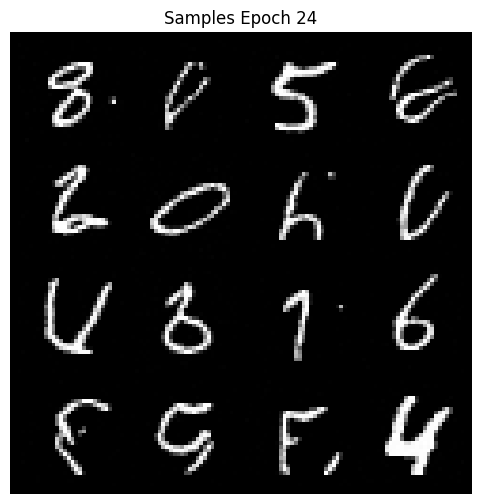

Epoch 25 | Step 0 | Loss: 24.27730
Epoch 25 | Step 100 | Loss: 22.82546
Epoch 25 | Step 200 | Loss: 25.87968
Epoch 25 | Step 300 | Loss: 26.02585
Epoch 25 | Step 400 | Loss: 21.56441
Epoch 25 | Step 500 | Loss: 24.96640
Epoch 25 | Step 600 | Loss: 25.03720
Epoch 25 | Step 700 | Loss: 24.23731
Epoch 25 | Step 800 | Loss: 28.31991
Epoch 25 | Step 900 | Loss: 24.89303
=== Epoch 25 Finished | Avg Loss: 24.35393 | Time: 52.6s ===
Epoch 26 | Step 0 | Loss: 23.16389
Epoch 26 | Step 100 | Loss: 24.46883
Epoch 26 | Step 200 | Loss: 28.33317
Epoch 26 | Step 300 | Loss: 22.08175
Epoch 26 | Step 400 | Loss: 28.24330
Epoch 26 | Step 500 | Loss: 29.30004
Epoch 26 | Step 600 | Loss: 20.87803
Epoch 26 | Step 700 | Loss: 25.04847
Epoch 26 | Step 800 | Loss: 29.44430
Epoch 26 | Step 900 | Loss: 21.73271
=== Epoch 26 Finished | Avg Loss: 24.12196 | Time: 52.7s ===
Epoch 27 | Step 0 | Loss: 30.38544
Epoch 27 | Step 100 | Loss: 26.12085
Epoch 27 | Step 200 | Loss: 27.98446
Epoch 27 | Step 300 | Loss: 27.46

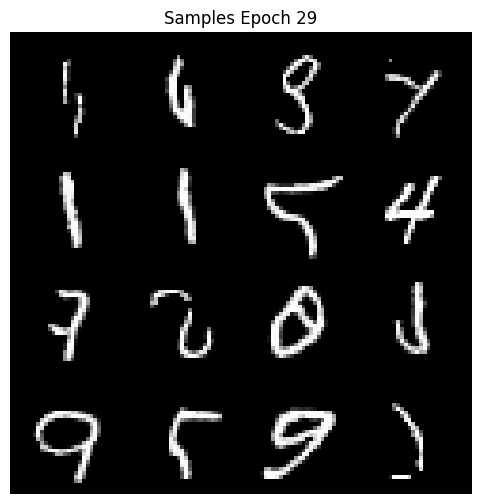

Training Complete.


In [ ]:
# Config and Training Loop
import time
import os
import torch
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt

cfg.lr = 1e-4
cfg.epochs = 30
cfg.n_steps = 100
cfg.step_lr = 2e-5

print(f"Config Updated: LR={cfg.lr}, Epochs={cfg.epochs}, Steps={cfg.n_steps}")

model = ScoreNet().to(cfg.device)
optimizer = optim.Adam(model.parameters(), lr=cfg.lr)

checkpoint_dir = '/content/drive/MyDrive/DGM_HW3/Part2_NCSN'
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt_path = os.path.join(checkpoint_dir, 'ncsn_checkpoint.pth')

start_epoch = 0
loss_history = []

if os.path.exists(ckpt_path):
    print(f"Loading checkpoint from {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=cfg.device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    loss_history = ckpt['loss_history']
    print(f"Resumed from epoch {start_epoch}")
else:
    print("Starting training from scratch...")

print("Training Started...")
model.train()

for epoch in range(start_epoch, cfg.epochs):
    epoch_loss = 0
    start_t = time.time()

    for batch_idx, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(cfg.device)

        optimizer.zero_grad()

        # Calculate Loss
        loss = calc_loss(model, real_imgs, sigmas)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} | Step {batch_idx} | Loss: {loss.item():.5f}")

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    time_taken = time.time() - start_t

    print(f"=== Epoch {epoch} Finished | Avg Loss: {avg_loss:.5f} | Time: {time_taken:.1f}s ===")

    # Save Checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss_history': loss_history
    }, ckpt_path)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print("Generating samples...")
        samples = annealed_langevin_sampling(model, sigmas,
                                             n_steps=cfg.n_steps,
                                             step_lr=cfg.step_lr)

        samples = (samples + 1) / 2
        samples = torch.clamp(samples, 0, 1)

        grid = torchvision.utils.make_grid(samples, nrow=4)
        grid_pil = transforms.functional.to_pil_image(grid)

        save_img_path = os.path.join(checkpoint_dir, f'sample_epoch_{epoch}.png')
        grid_pil.save(save_img_path)

        plt.figure(figsize=(6,6))
        plt.imshow(grid_pil)
        plt.axis('off')
        plt.title(f"Samples Epoch {epoch}")
        plt.show()

print("Training Complete.")

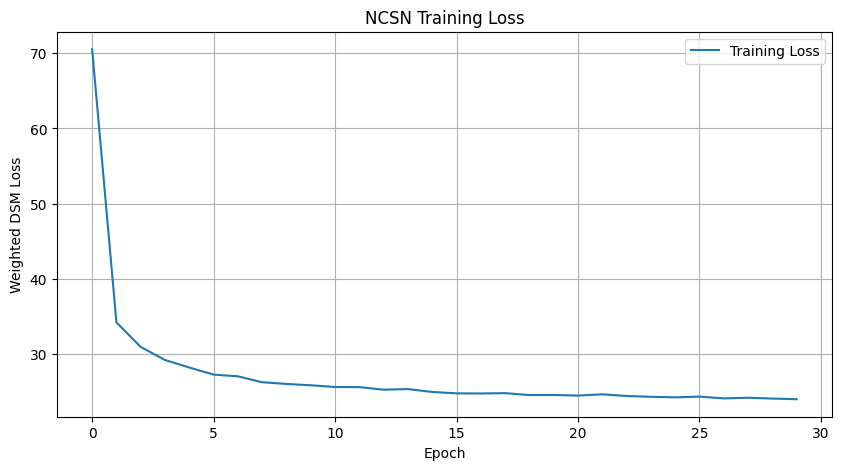

In [ ]:
# Plot Loss
import torchvision

plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Weighted DSM Loss')
plt.title('NCSN Training Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(checkpoint_dir, 'loss_curve.png'))
plt.show()

Loaded model from Epoch 29
Generating Final Samples...


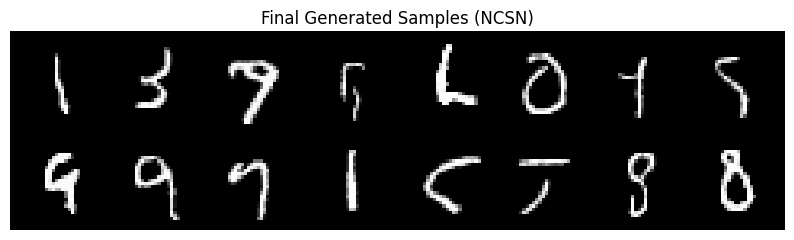

In [ ]:
# Final High-Quality Generation

checkpoint_path = os.path.join(checkpoint_dir, 'ncsn_checkpoint.pth')
if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=cfg.device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Loaded model from Epoch {ckpt['epoch']}")

print("Generating Final Samples...")
final_samples = annealed_langevin_sampling(model, sigmas, n_steps=150, step_lr=2e-5)

final_samples = (final_samples + 1) / 2
final_samples = torch.clamp(final_samples, 0, 1)

grid = torchvision.utils.make_grid(final_samples, nrow=8)
grid_pil = transforms.functional.to_pil_image(grid)

plt.figure(figsize=(10, 10))
plt.imshow(grid_pil)
plt.axis('off')
plt.title("Final Generated Samples (NCSN)")
plt.show()

# Save
grid_pil.save(os.path.join(checkpoint_dir, 'final_samples.png'))

In [ ]:
# Visualize Denoising Process
import matplotlib.pyplot as plt

def visualize_denoising_process(model, sigmas, n_samples=3, n_steps=100, step_lr=2e-5):
    model.eval()

    x = torch.rand(n_samples, 1, 28, 28, device=cfg.device)

    history = []
    history.append(x.clone().detach().cpu())

    for i, sigma in enumerate(sigmas):
        sigma_val = sigma.item()
        step_size = step_lr * (sigma_val / sigmas[-1].item()) ** 2

        for t in range(n_steps):
            sigma_batch = torch.full((n_samples,), sigma_val, device=cfg.device)
            with torch.no_grad():
                score = model(x, sigma_batch)

            z = torch.randn_like(x)
            x = x + step_size * score + np.sqrt(2 * step_size) * z

        history.append(x.clone().detach().cpu())

    num_levels = len(sigmas)
    indices_to_show = np.linspace(0, num_levels, 11, dtype=int) # 0 to L

    fig, axes = plt.subplots(n_samples, len(indices_to_show), figsize=(20, 6))

    def denorm(img_tensor):
        return torch.clamp((img_tensor + 1) / 2, 0, 1).squeeze()

    print(f"Visualizing {n_samples} samples across noise levels: {sigmas[0].item():.2f} -> {sigmas[-1].item():.4f}")

    for row in range(n_samples):
        for col_idx, history_idx in enumerate(indices_to_show):
            img = history[history_idx][row]

            ax = axes[row, col_idx]
            ax.imshow(denorm(img), cmap='gray')
            ax.axis('off')

            if row == 0:
                if history_idx == 0:
                    ax.set_title("Initial Noise")
                elif history_idx == num_levels:
                    ax.set_title("Final Result")
                else:
                    current_sigma = sigmas[history_idx-1].item()
                    ax.set_title(f"$\sigma$={current_sigma:.2f}")

    plt.tight_layout()
    save_path = os.path.join(checkpoint_dir, 'denoising_process.png')
    plt.savefig(save_path)
    plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3799498640.py:51: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$\sigma$={current_sigma:.2f}")


Visualizing 3 samples across noise levels: 30.00 -> 0.0100


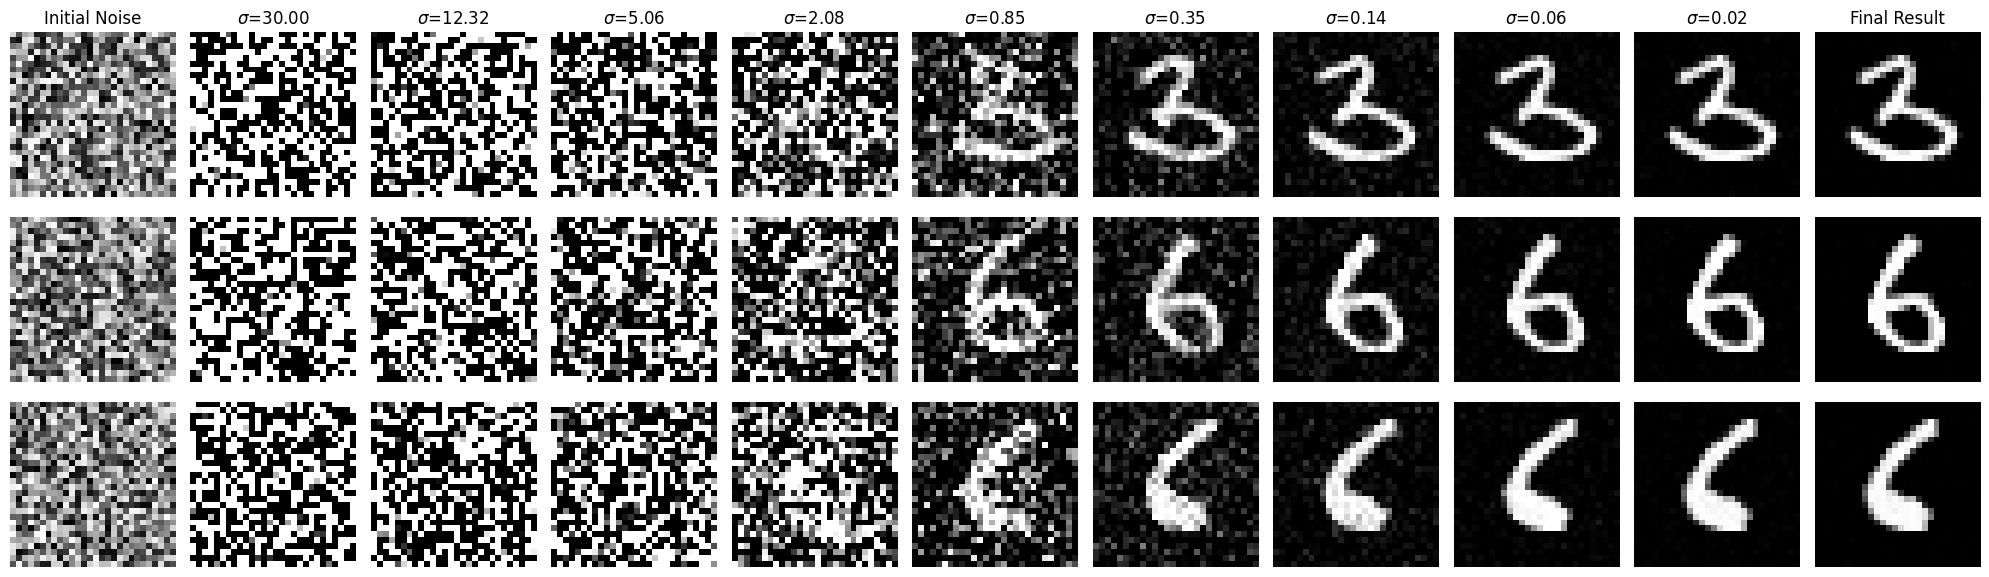

In [ ]:
visualize_denoising_process(model, sigmas, n_samples=3, n_steps=cfg.n_steps, step_lr=cfg.step_lr)

## Conditional Part

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import os

class ConditionalConfig:
    sigma_begin = 30.0
    sigma_end = 0.01
    num_levels = 10
    batch_size = 64
    lr = 2e-4
    epochs = 30

    # Sampling params
    n_steps = 150
    step_lr = 2e-5

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = ConditionalConfig()
print(f"Device: {cfg.device}")

# Data Preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download Datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, drop_last=True)

sigmas = torch.exp(torch.linspace(
    np.log(cfg.sigma_begin),
    np.log(cfg.sigma_end),
    cfg.num_levels
)).to(cfg.device)

print(f"Sigmas: {sigmas}")

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 510kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.75MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]


Sigmas: tensor([3.0000e+01, 1.2325e+01, 5.0632e+00, 2.0801e+00, 8.5454e-01, 3.5106e-01,
        1.4422e-01, 5.9251e-02, 2.4341e-02, 1.0000e-02], device='cuda:0')


In [2]:
# Network Components

class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim=256, scale=30.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class Dense(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)
        self.act = nn.SiLU()
    def forward(self, x):
        return self.dense(self.act(x))

class AdaptiveResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, embed_dim=512): # Increased default for concat
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

        self.embed_layers = nn.Linear(embed_dim, 2 * in_channels)

    def forward(self, x, embed):
        h = self.norm1(x)

        style = self.embed_layers(embed)
        style = style.unsqueeze(2).unsqueeze(3)
        scale, shift = style.chunk(2, dim=1)

        h = h * (1 + scale) + shift

        h = F.silu(h)
        h = self.conv1(h)

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + self.shortcut(x)

In [4]:
# Conditional ScoreNet Architecture

class ConditionalScoreNet(nn.Module):
    def __init__(self, num_classes=10, embed_dim=256):
        super().__init__()

        self.noise_embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=embed_dim),
            Dense(embed_dim, embed_dim)
        )

        self.class_embed = nn.Embedding(num_classes, embed_dim)

        combined_dim = embed_dim * 2

        self.input_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)

        self.enc1 = AdaptiveResBlock(64, 64, embed_dim=combined_dim)
        self.down1 = nn.AvgPool2d(2)

        self.enc2 = AdaptiveResBlock(64, 128, embed_dim=combined_dim)
        self.down2 = nn.AvgPool2d(2)

        self.enc3 = AdaptiveResBlock(128, 256, embed_dim=combined_dim)

        self.dec1 = AdaptiveResBlock(256 + 128, 128, embed_dim=combined_dim)
        self.dec2 = AdaptiveResBlock(128 + 64, 64, embed_dim=combined_dim)

        self.output_conv = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x, sigma, y):

        e_noise = self.noise_embed(sigma)
        e_class = self.class_embed(y)

        embed = torch.cat([e_noise, e_class], dim=1) # (B, 512)

        h1 = self.input_conv(x)
        h1 = self.enc1(h1, embed)

        h2 = self.down1(h1)
        h2 = self.enc2(h2, embed)

        h3 = self.down2(h2)
        h3 = self.enc3(h3, embed)

        h_up1 = F.interpolate(h3, scale_factor=2, mode='nearest')
        h_up1 = torch.cat([h_up1, h2], dim=1)
        h4 = self.dec1(h_up1, embed)

        h_up2 = F.interpolate(h4, scale_factor=2, mode='nearest')
        h_up2 = torch.cat([h_up2, h1], dim=1)
        h5 = self.dec2(h_up2, embed)

        out = self.output_conv(h5)

        out = out / sigma[:, None, None, None]

        return out

In [5]:
model = ConditionalScoreNet().to(cfg.device)

In [6]:
# Loss and Sampling Functions

def calc_conditional_loss(model, x, y, sigmas):
    B = x.shape[0]
    sigma_indices = torch.randint(0, len(sigmas), (B,), device=x.device)
    current_sigmas = sigmas[sigma_indices]

    z = torch.randn_like(x)
    sigmas_reshaped = current_sigmas.view(B, 1, 1, 1)
    x_tilde = x + sigmas_reshaped * z

    pred_score = model(x_tilde, current_sigmas, y)

    target = -z / sigmas_reshaped
    loss = 0.5 * ((pred_score * sigmas_reshaped + z) ** 2).sum() / B
    return loss

@torch.no_grad()
def conditional_sampler(model, sigmas, target_labels, n_steps=150, step_lr=2e-5):
    model.eval()
    B = target_labels.shape[0]

    x = torch.rand(B, 1, 28, 28, device=cfg.device)

    for i, sigma in enumerate(sigmas):
        sigma_val = sigma.item()
        step_size = step_lr * (sigma_val / sigmas[-1].item()) ** 2
        sigma_batch = torch.full((B,), sigma_val, device=cfg.device)

        for t in range(n_steps):
            score = model(x, sigma_batch, target_labels)

            z = torch.randn_like(x)
            x = x + step_size * score + np.sqrt(2 * step_size) * z

    return x

Starting Conditional Training...
Epoch 1/30 | Loss: 54.29006 | Time: 54.4s
Epoch 2/30 | Loss: 30.83876 | Time: 54.5s
Epoch 3/30 | Loss: 28.22754 | Time: 53.5s
Epoch 4/30 | Loss: 27.12244 | Time: 53.5s
Epoch 5/30 | Loss: 26.50828 | Time: 53.8s
Epoch 6/30 | Loss: 26.24173 | Time: 53.6s
Epoch 7/30 | Loss: 25.71864 | Time: 53.4s
Epoch 8/30 | Loss: 25.37870 | Time: 53.4s
Epoch 9/30 | Loss: 25.44313 | Time: 53.2s
Epoch 10/30 | Loss: 24.94559 | Time: 53.2s
Epoch 11/30 | Loss: 24.71822 | Time: 53.1s
Epoch 12/30 | Loss: 24.85737 | Time: 53.1s
Epoch 13/30 | Loss: 24.68796 | Time: 53.1s
Epoch 14/30 | Loss: 24.69766 | Time: 53.2s
Epoch 15/30 | Loss: 24.40465 | Time: 52.9s
Epoch 16/30 | Loss: 24.49654 | Time: 53.0s
Epoch 17/30 | Loss: 24.21817 | Time: 52.9s
Epoch 18/30 | Loss: 24.27543 | Time: 53.1s
Epoch 19/30 | Loss: 23.99518 | Time: 52.9s
Epoch 20/30 | Loss: 23.87741 | Time: 53.0s
Epoch 21/30 | Loss: 23.87067 | Time: 52.9s
Epoch 22/30 | Loss: 23.69813 | Time: 53.0s
Epoch 23/30 | Loss: 23.89544 |

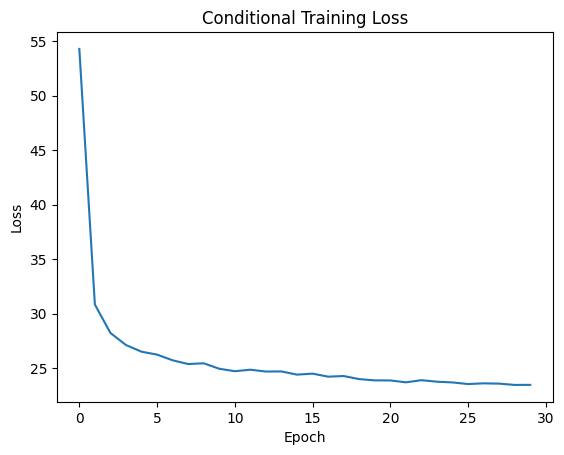

Training Complete.


In [7]:
# Training Loop
import time

optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
loss_history = []

checkpoint_dir = '/content/drive/MyDrive/DGM_HW3/Part2_Conditional'
os.makedirs(checkpoint_dir, exist_ok=True)

print("Starting Conditional Training...")
model.train()

for epoch in range(cfg.epochs):
    epoch_loss = 0
    start = time.time()

    for x, y in train_loader:
        x, y = x.to(cfg.device), y.to(cfg.device)

        optimizer.zero_grad()
        loss = calc_conditional_loss(model, x, y, sigmas)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}/{cfg.epochs} | Loss: {avg_loss:.5f} | Time: {time.time()-start:.1f}s")

    # Save
    if (epoch+1) % 5 == 0:
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, f'ckpt_epoch_{epoch+1}.pth'))

plt.figure()
plt.plot(loss_history)
plt.title("Conditional Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
print("Training Complete.")

In [8]:
def generate_conditional_grid(model, sigmas):
    labels = []
    for i in range(10):
        labels.append(torch.full((10,), i, dtype=torch.long))

    labels = torch.cat(labels).to(cfg.device)

    samples = conditional_sampler(model, sigmas, labels, n_steps=cfg.n_steps, step_lr=cfg.step_lr)

    samples = (samples + 1) / 2
    samples = torch.clamp(samples, 0, 1)

    grid = torchvision.utils.make_grid(samples, nrow=10) # 10 columns
    grid_pil = transforms.functional.to_pil_image(grid)

    plt.figure(figsize=(10, 10))
    plt.imshow(grid_pil)
    plt.axis('off')
    plt.title("Conditional Generation (Rows: 0-9)")
    plt.show()

    # Save
    grid_pil.save(os.path.join(checkpoint_dir, 'conditional_grid.png'))

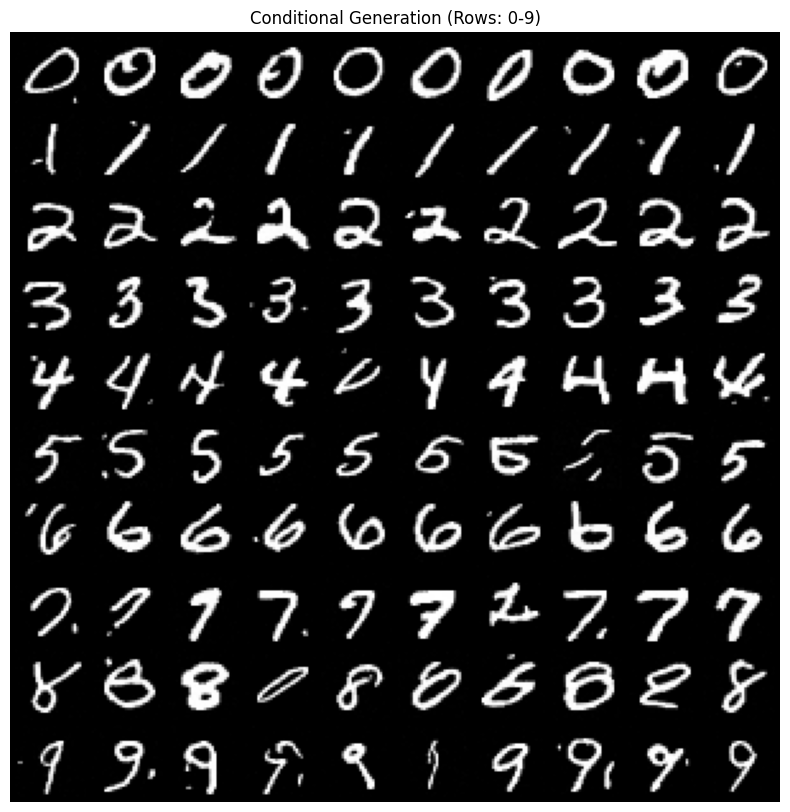

In [10]:
generate_conditional_grid(model, sigmas)